In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pickle as pkl

In [19]:
# Build the arrays

fno_dict = pkl.load(open('fno/fno_dict.pkl', 'rb'))
cnn_dict = pkl.load(open('cnn/cnn_dict.pkl', 'rb'))
mlp_dict = pkl.load(open('mlp/mlp_dict.pkl', 'rb'))

fno_params = np.array([fno_dict[i]['metrics_total'][0][0] for i in fno_dict.keys()])
fno_npvr2 = np.array([fno_dict[i]['metrics_total'][0][5] for i in fno_dict.keys()])
cnn_params = np.array([cnn_dict[i]['metrics_total'][0][0] for i in cnn_dict.keys()])
cnn_npvr2 = np.array([cnn_dict[i]['metrics_total'][0][5] for i in cnn_dict.keys()])
mlp_params = np.array([mlp_dict[i]['metrics_total'][0][0] for i in mlp_dict.keys()])
mlp_npvr2 = np.array([mlp_dict[i]['metrics_total'][0][5] for i in mlp_dict.keys()])

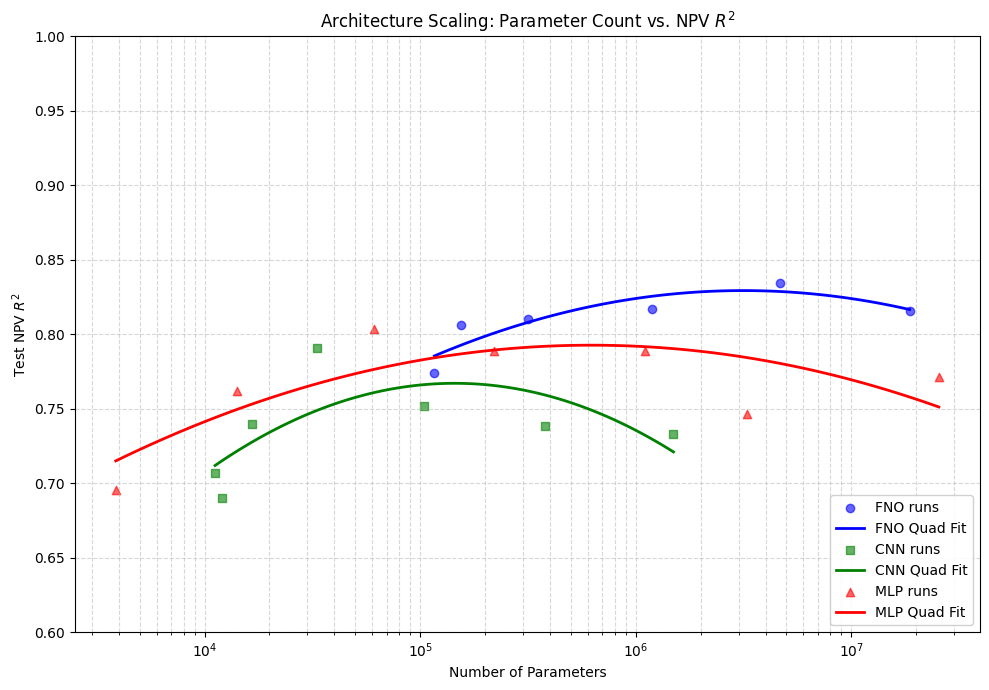

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def get_quadratic_fit(params, r2_scores, num_points=100):
    log_params = np.log10(params)
    coefs = np.polyfit(log_params, r2_scores, 2)
    p_min, p_max = np.min(params), np.max(params)
    dense_params = np.logspace(np.log10(p_min), np.log10(p_max), num_points)
    fit_r2 = np.polyval(coefs, np.log10(dense_params))
    return dense_params, fit_r2

fno_curve_p, fno_curve_r2 = get_quadratic_fit(fno_params, fno_npvr2)
cnn_curve_p, cnn_curve_r2 = get_quadratic_fit(cnn_params, cnn_npvr2)
mlp_curve_p, mlp_curve_r2 = get_quadratic_fit(mlp_params, mlp_npvr2)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(fno_params, fno_npvr2, color='blue', marker='o', alpha=0.6, label='FNO runs')
ax.plot(fno_curve_p, fno_curve_r2, color='blue', linestyle='-', linewidth=2, label='FNO Quad Fit')
ax.scatter(cnn_params, cnn_npvr2, color='green', marker='s', alpha=0.6, label='CNN runs')
ax.plot(cnn_curve_p, cnn_curve_r2, color='green', linestyle='-', linewidth=2, label='CNN Quad Fit')
ax.scatter(mlp_params, mlp_npvr2, color='red', marker='^', alpha=0.6, label='MLP runs')
ax.plot(mlp_curve_p, mlp_curve_r2, color='red', linestyle='-', linewidth=2, label='MLP Quad Fit')
ax.set_xscale('log')
ax.set_ylim(0.6, 1)
ax.set_xlabel('Number of Parameters')
ax.set_ylabel(r'Test NPV $R^2$')
ax.set_title(r'Architecture Scaling: Parameter Count vs. NPV $R^2$')
ax.grid(True, which="both", ls="--", alpha=0.5)
ax.legend(loc='lower right', framealpha=0.9)
plt.tight_layout()
plt.savefig('pareto_front_quad.svg', dpi=300)